<a href="https://colab.research.google.com/github/joyekansh/Ml-projects/blob/main/1D_non_linear_Poisson_Boltzmann_PINNs_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import tensorflow as tf
import numpy as np
import deepxde as dde

geom = dde.geometry.Interval(0,1)
k = 1.0
psi_0 = -0.05
gamma = np.tanh(psi_0/4)

def exact_sol(x):
  return 4*(np.arctanh(gamma*(np.exp(-k*x))))

def pde(x,phi):
  dyy_dxx = dde.grad.hessian(phi,x)
  elem = (k**2)*(tf.sinh(phi))
  return dyy_dxx - elem

def boundary_left(x,boundary_on):
  return boundary_on and dde.utils.isclose(x[0],0)

def boundary_right(x,boundary_on):
  return boundary_on and dde.utils.isclose(x[0],1)

bc_left = dde.icbc.DirichletBC(geom, lambda x: psi_0, boundary_left)
bc_right = dde.icbc.DirichletBC(geom, lambda x: exact_sol(x), boundary_right)

data = dde.data.PDE(
    geom,
    pde,
    [bc_left, bc_right],
    num_domain=16,
    num_boundary=2,
    solution=exact_sol,
    num_test=100
)

layer_size = [1] + [50]*3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size,activation,initializer)

model = dde.Model(data,net)
model.compile("adam",lr=0.001,metrics=["l2 relative error"])

loss_history, train_state = model.train(iterations=1000)

Compiling model...
'compile' took 0.004097 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7a415e2db060>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7a415e2db060>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7a415e2f4fe0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7a415e2f4fe0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric   
0         [4.05e-02, 2.50e-03, 6.21e-02]    [4.23e-02, 2.50e-03, 6.21e-02]    [4.96e+00]    
1000      [9.24e-07, 1.27e-09, 1.49e-11]    [7.11e-07, 1.27e-09, 1.49e-11]    [9.39e-04]    

Best model at step 1000:
  train loss: 9.25e-07
  test loss: 7.13e-07
  test metric: [9.39e-04]

'train' took 3.511971 s



<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_11291/387259393.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Potential $\phi$')


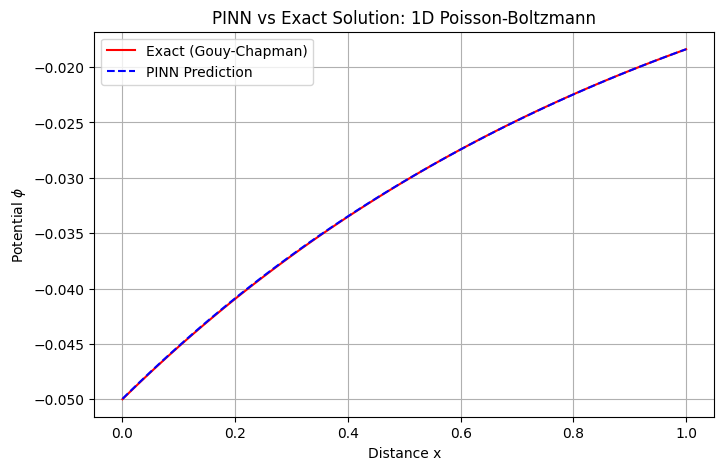

In [10]:
import matplotlib.pyplot as plt

x_test = np.linspace(0, 1, 100).reshape(-1, 1)
phi_pred = model.predict(x_test)
phi_exact = exact_sol(x_test)

plt.figure(figsize=(8, 5))
plt.plot(x_test, phi_exact, 'r-', label='Exact (Gouy-Chapman)')
plt.plot(x_test, phi_pred, 'b--', label='PINN Prediction')
plt.xlabel('Distance x')
plt.ylabel('Potential $\phi$')
plt.title('PINN vs Exact Solution: 1D Poisson-Boltzmann')
plt.legend()
plt.grid(True)
plt.show()
